# FEA ML Training Workflow

## Overview

This notebook guides you through the complete workflow for training machine learning models to predict Finite Element Analysis (FEA) results. The pipeline includes:

1. **Dataset Generation** - Create synthetic FEA datasets using different sampling strategies
2. **Input Visualization** - Understand the parameter space as 3D point clouds
3. **Model Training** - Train neural network models (GCN and Transformer) on the generated data
4. **Results Visualization** - Compare predictions with ground truth values

### Key Components

- **Sampling Strategies**: Different methods to explore the parameter space
  - `random`: Random sampling from the parameter space
  - `lhs`: Latin Hypercube Sampling for better coverage
  - `sobol`: Quasi-random Sobol sequence for systematic exploration

- **Model Types**: Different neural network architectures
  - `gcn`: Graph Convolutional Networks for handling point cloud data
  - `transformer`: Transformer-based models for sequence modeling

---

## Step 1: Setup - Initialize Paths and Configuration

This section sets up the directory structure and defines the configurations for the training pipeline.

**What happens here:**
- Import all required modules from the `src` package
- Define paths for data, models, and output directories
- Configure which sampling strategies and model types to use
- Create a screenshots directory for saving results

In [1]:
from pathlib import Path

# Import custom modules
from src.generate_dataset import generate_dataset
from src.input_visualizer import PointCloudVisualizer
from src.rom_model import ROMTrainer
from src.visualizer import ROMVisualizer

# Define paths
data_dir = Path("mock_data")
model_dir = Path("models")

# Configuration: Which models and sampling strategies to use
model_types = ["gcn", "transformer"]  # Neural network architectures
samplings = ["random", "lhs", "sobol"]  # Sampling strategies to test
# Note: "taguchi" is available for testing with fewer samples

# Create output directory for screenshots
Path("screenshots").mkdir(exist_ok=True)

print("✓ Setup complete!")
print(f"  Data directory: {data_dir.absolute()}")
print(f"  Model directory: {model_dir.absolute()}")
print(f"  Sampling strategies: {', '.join(samplings)}")
print(f"  Model types: {', '.join(model_types)}")

2026-03-31 15:33:43.041012: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 15:33:43.313805: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Setup complete!
  Data directory: /mnt/e/jimit.vyas/scripts/fea-ml-training/mock_data
  Model directory: /mnt/e/jimit.vyas/scripts/fea-ml-training/models
  Sampling strategies: random, lhs, sobol
  Model types: gcn, transformer


## Step 2: Dataset Generation

Generate synthetic FEA datasets using different sampling strategies to explore the parameter space.

**What happens here:**
- For each sampling strategy (random, LHS, Sobol), we create 600 samples
- Each sample represents a different geometry and loading condition
- The samples are used to train and validate the ROM models

**Dataset Configuration:**
- Number of samples: 600
- Parameter space includes: length, width, depth, load
- Output: displacement and stress fields

**Note:** This step may take several minutes depending on your system.

In [2]:
# Generate datasets for each sampling strategy
for sampling in samplings:
    print(f"\n{'='*60}")
    print(f"Generating dataset for {sampling.upper()} sampling...")
    print(f"{'='*60}")
    
    generate_dataset(
        n_samples=600,           # Number of FEA simulations to run
        sampling=sampling,       # Sampling strategy (random, lhs, sobol)
        output_dir=data_dir/sampling,  # Save location
        taguchi_levels=4         # Levels for Taguchi sampling (if applicable)
    )
    
    print(f"✓ {sampling.upper()} dataset generated successfully!")


Generating dataset for RANDOM sampling...
Data found. Skipping generation
✓ RANDOM dataset generated successfully!

Generating dataset for LHS sampling...
Data found. Skipping generation
✓ LHS dataset generated successfully!

Generating dataset for SOBOL sampling...
Data found. Skipping generation
✓ SOBOL dataset generated successfully!


## Step 3: Input Data Visualization

Visualize the parameter space as 3D point clouds to understand the distribution of samples.

**What happens here:**
- Load the design table (parameter values) from the generated dataset
- Create a 3D visualization of the parameter space
- Shows how different sampling strategies distribute points in the 3D/4D parameter space

**Visualization Settings:**
- Using symmetric color scale for balanced visualization
- Interactive 3D plot (you can rotate, zoom, pan)


Visualizing input data for RANDOM sampling...


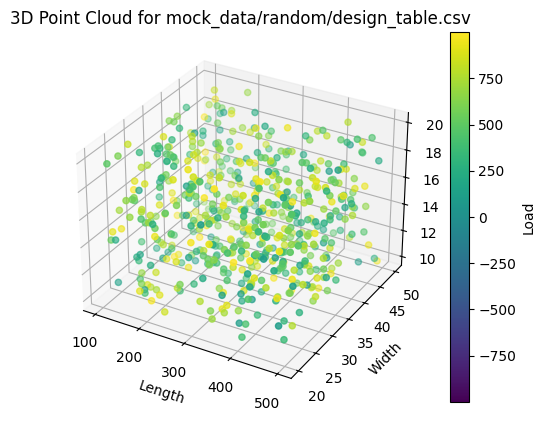

✓ RANDOM parameter space visualized!

Visualizing input data for LHS sampling...


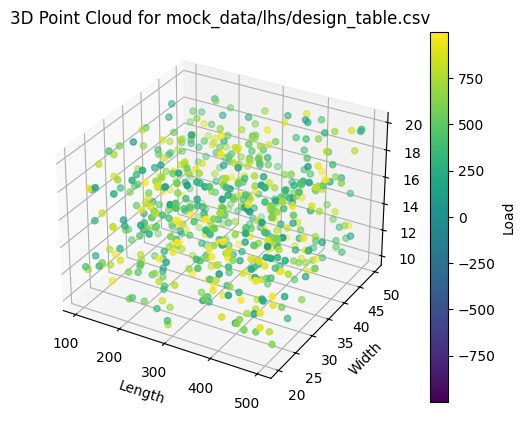

✓ LHS parameter space visualized!

Visualizing input data for SOBOL sampling...


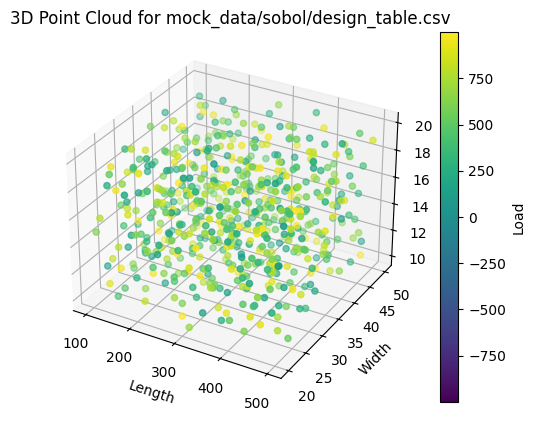

✓ SOBOL parameter space visualized!


In [3]:
# Visualize input data for each sampling strategy
for sampling in samplings:
    print(f"\nVisualizing input data for {sampling.upper()} sampling...")
    
    viz = PointCloudVisualizer(
        csv_path=data_dir/sampling/"design_table.csv"
    )
    viz.load_data()
    viz.plot(symmetric_color_scale=True)
    
    print(f"✓ {sampling.upper()} parameter space visualized!")

## Step 4: Model Training

Train neural network models (GCN and Transformer) on the generated datasets.

**What happens here:**
- For each sampling strategy, we train two different model architectures
- GCN (Graph Convolutional Networks): Processes point cloud data through graph convolutions
- Transformer: Processes sequences of points through attention mechanisms
- Each model learns to predict FEA outputs (displacement/stress) from input parameters

**Training Details:**
- Models are trained using the generated datasets
- Training progress is logged in the `logs/` directory
- Checkpoints are saved in the `models/` directory
- Each model gets its own subdirectory: `models/{model_type}/{sampling}/`

**Note:** This is the most computationally intensive step. Monitor GPU/CPU usage and expect it to take time.

In [4]:
# Train models for each sampling strategy
for sampling in samplings:
    print(f"\n{'='*60}")
    print(f"Training models for {sampling.upper()} sampling")
    print(f"{'='*60}")
    
    for model_type in model_types:
        print(f"\n>> Training {model_type.upper()} model...")
        
        trainer = ROMTrainer(
            model_type=model_type,           # GCN or Transformer
            data_dir=data_dir/sampling,      # Dataset location
            model_dir=model_dir/model_type/sampling  # Save location
        )
        trainer.train()
        
        print(f"✓ {model_type.upper()} training complete!")
        print(f"  Model saved to: {model_dir/model_type/sampling}")


Training models for RANDOM sampling

>> Training GCN model...
✓ GCN training complete!
  Model saved to: models/gcn/random

>> Training TRANSFORMER model...
✓ TRANSFORMER training complete!
  Model saved to: models/transformer/random

Training models for LHS sampling

>> Training GCN model...
✓ GCN training complete!
  Model saved to: models/gcn/lhs

>> Training TRANSFORMER model...
✓ TRANSFORMER training complete!
  Model saved to: models/transformer/lhs

Training models for SOBOL sampling

>> Training GCN model...
✓ GCN training complete!
  Model saved to: models/gcn/sobol

>> Training TRANSFORMER model...
✓ TRANSFORMER training complete!
  Model saved to: models/transformer/sobol


## Step 5: Results Visualization - Predictions vs Ground Truth

Visualize the model predictions and compare them with ground truth FEA results.

**What happens here:**
- Load trained models
- Make predictions for a specific geometry and loading case
- Visualize displacement and stress fields
- Compare predicted results with actual FEA simulations

**Test Case Parameters:**
- Length: 280 mm
- Width: 25 mm
- Depth: 12 mm
- Load: 900 N

**Output:**
- Visual predictions saved as screenshots
- Files saved to: `screenshots/predictions_{model_type}_{sampling}.png`


Generating predictions for RANDOM sampling

>> Visualizing GCN predictions...


e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


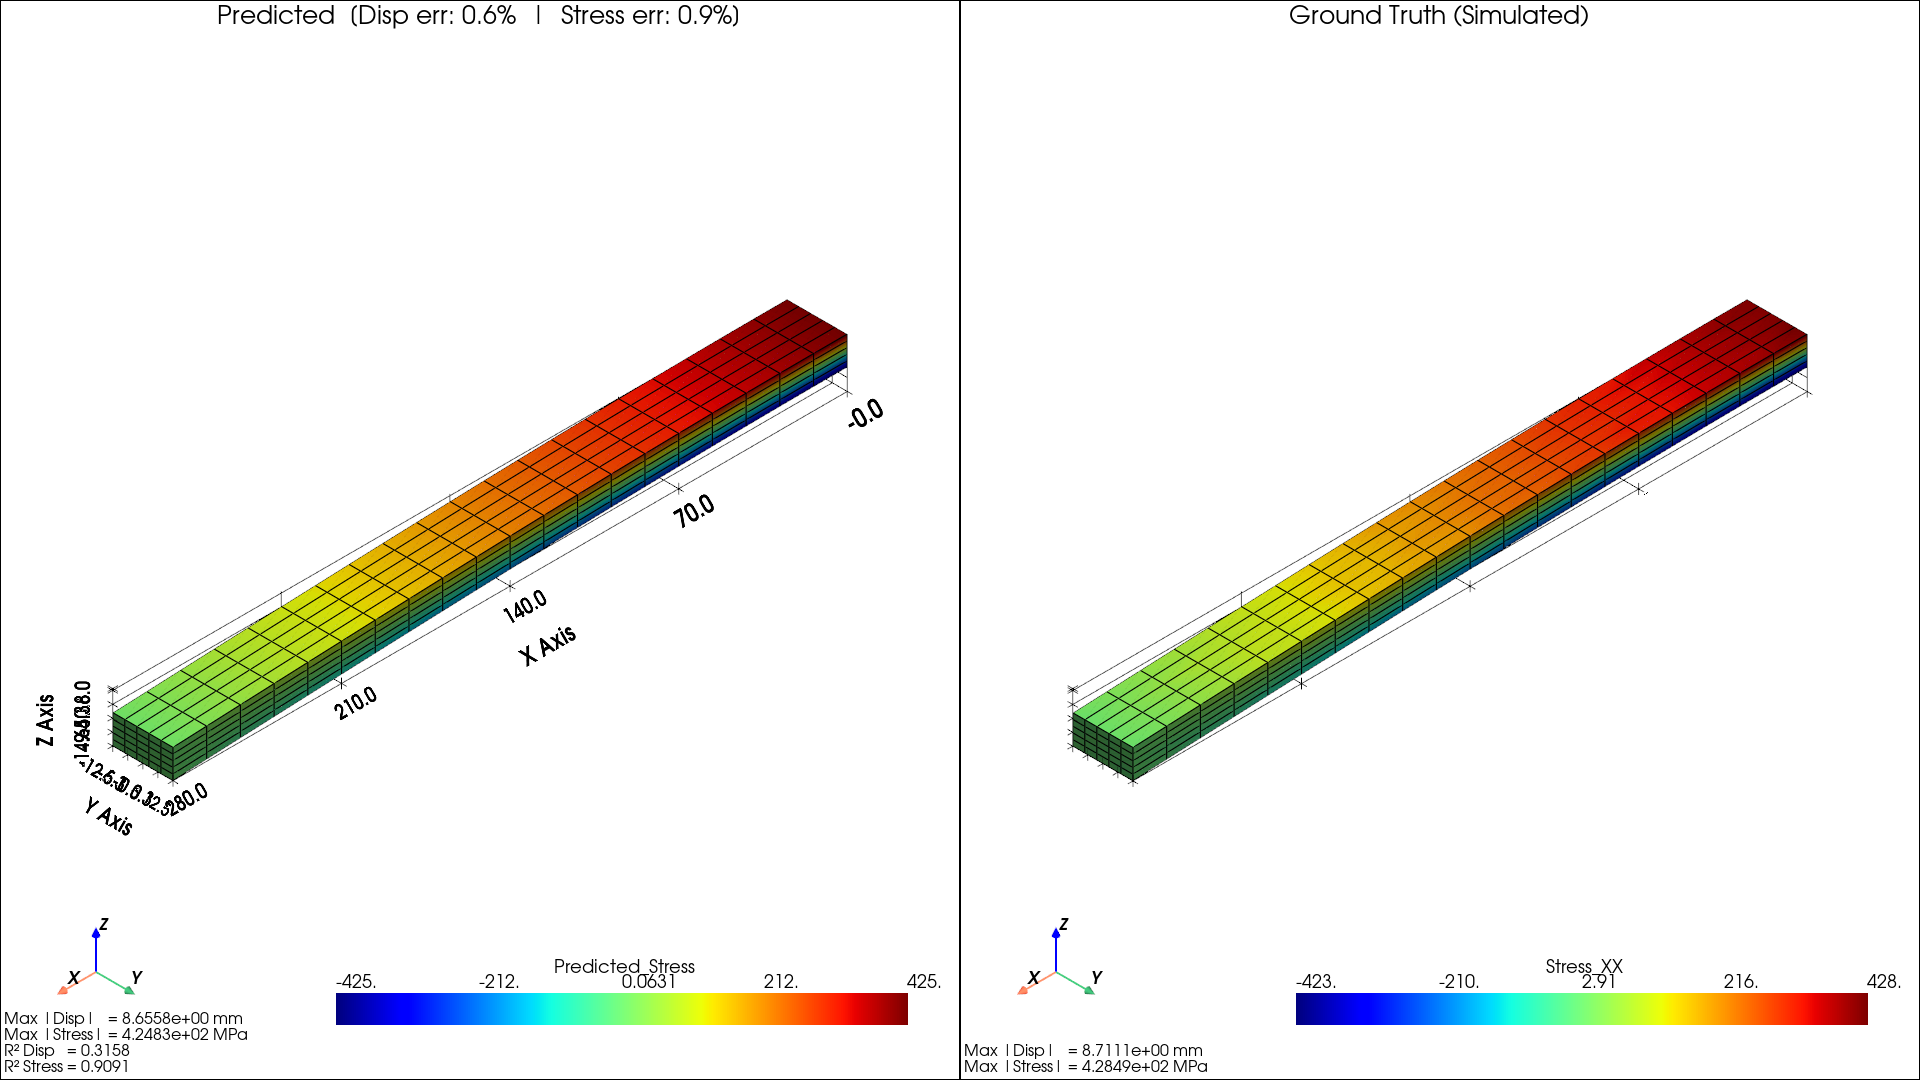

✓ Visualization saved to: e:\jimit.vyas\scripts\fea-ml-training\screenshots\predictions_gcn_random.png

>> Visualizing TRANSFORMER predictions...


e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


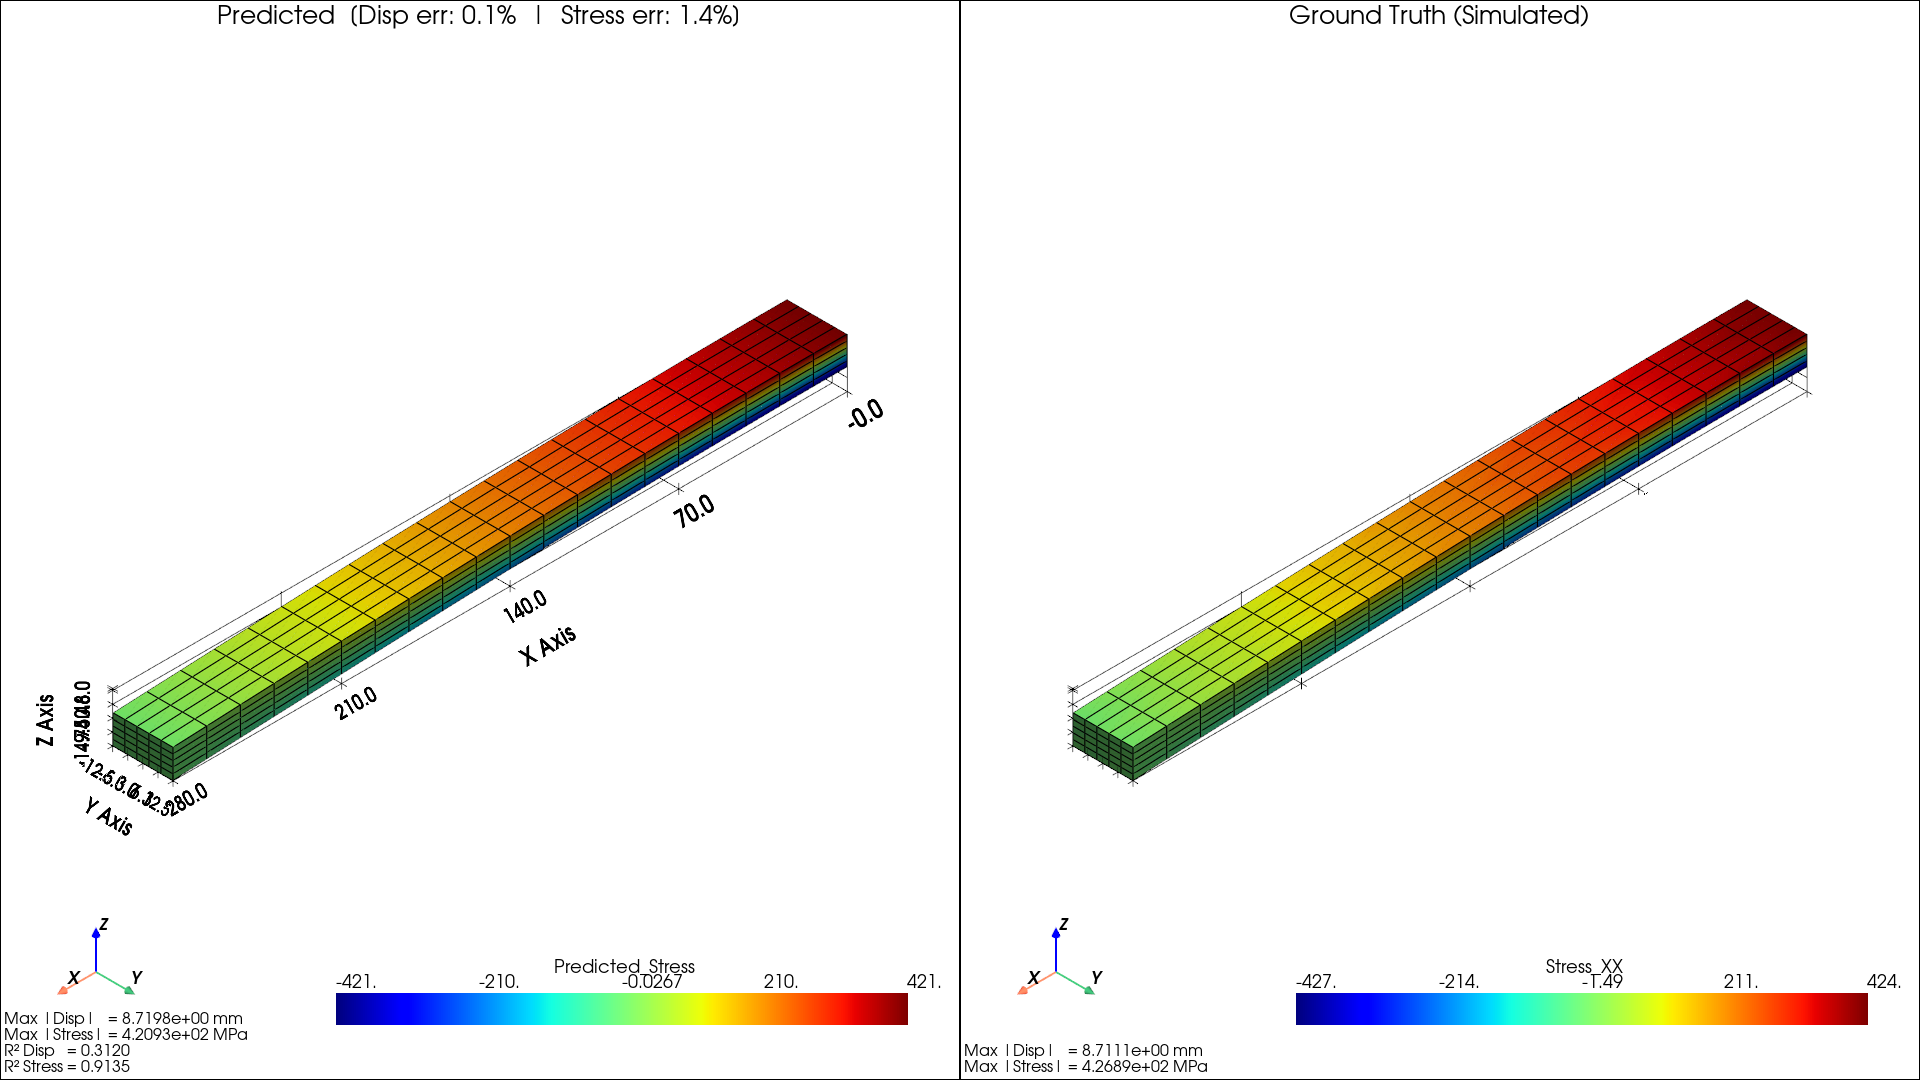

✓ Visualization saved to: e:\jimit.vyas\scripts\fea-ml-training\screenshots\predictions_transformer_random.png

Generating predictions for LHS sampling

>> Visualizing GCN predictions...


e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


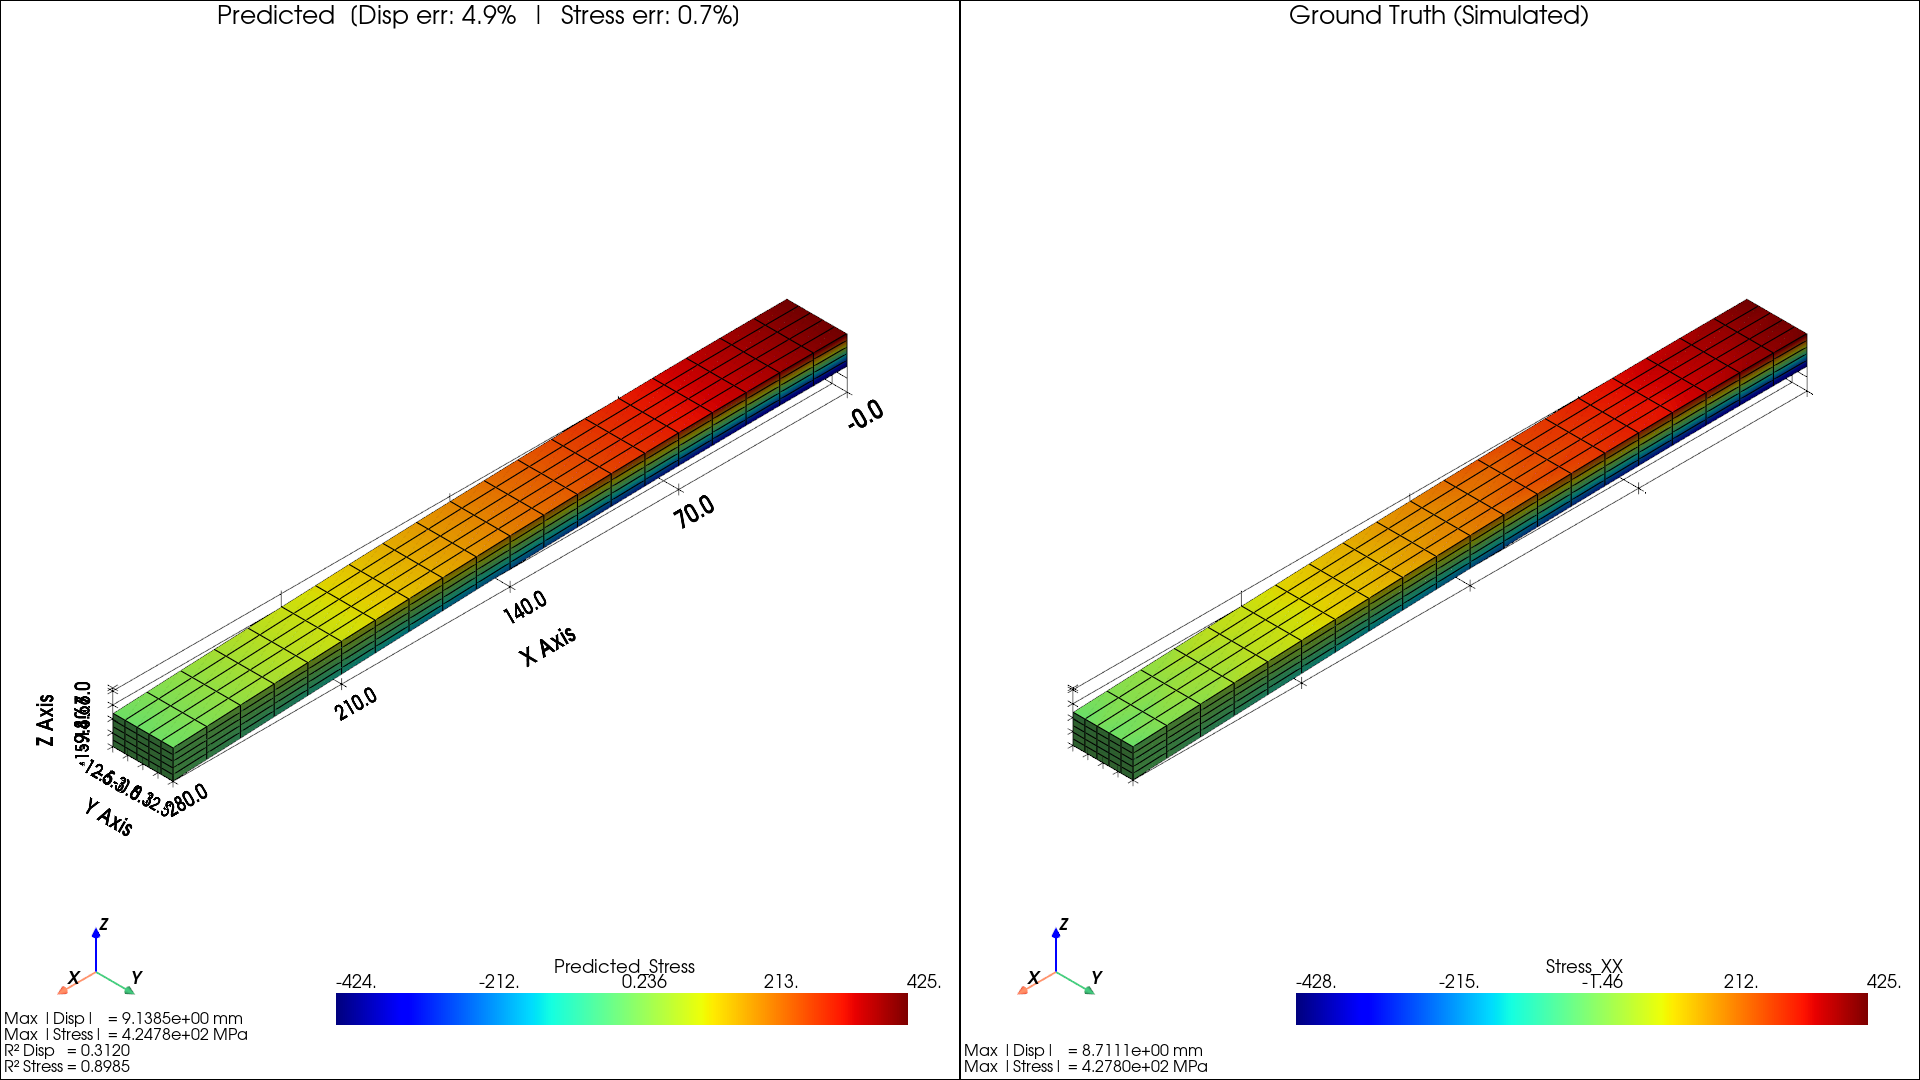

✓ Visualization saved to: e:\jimit.vyas\scripts\fea-ml-training\screenshots\predictions_gcn_lhs.png

>> Visualizing TRANSFORMER predictions...


e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


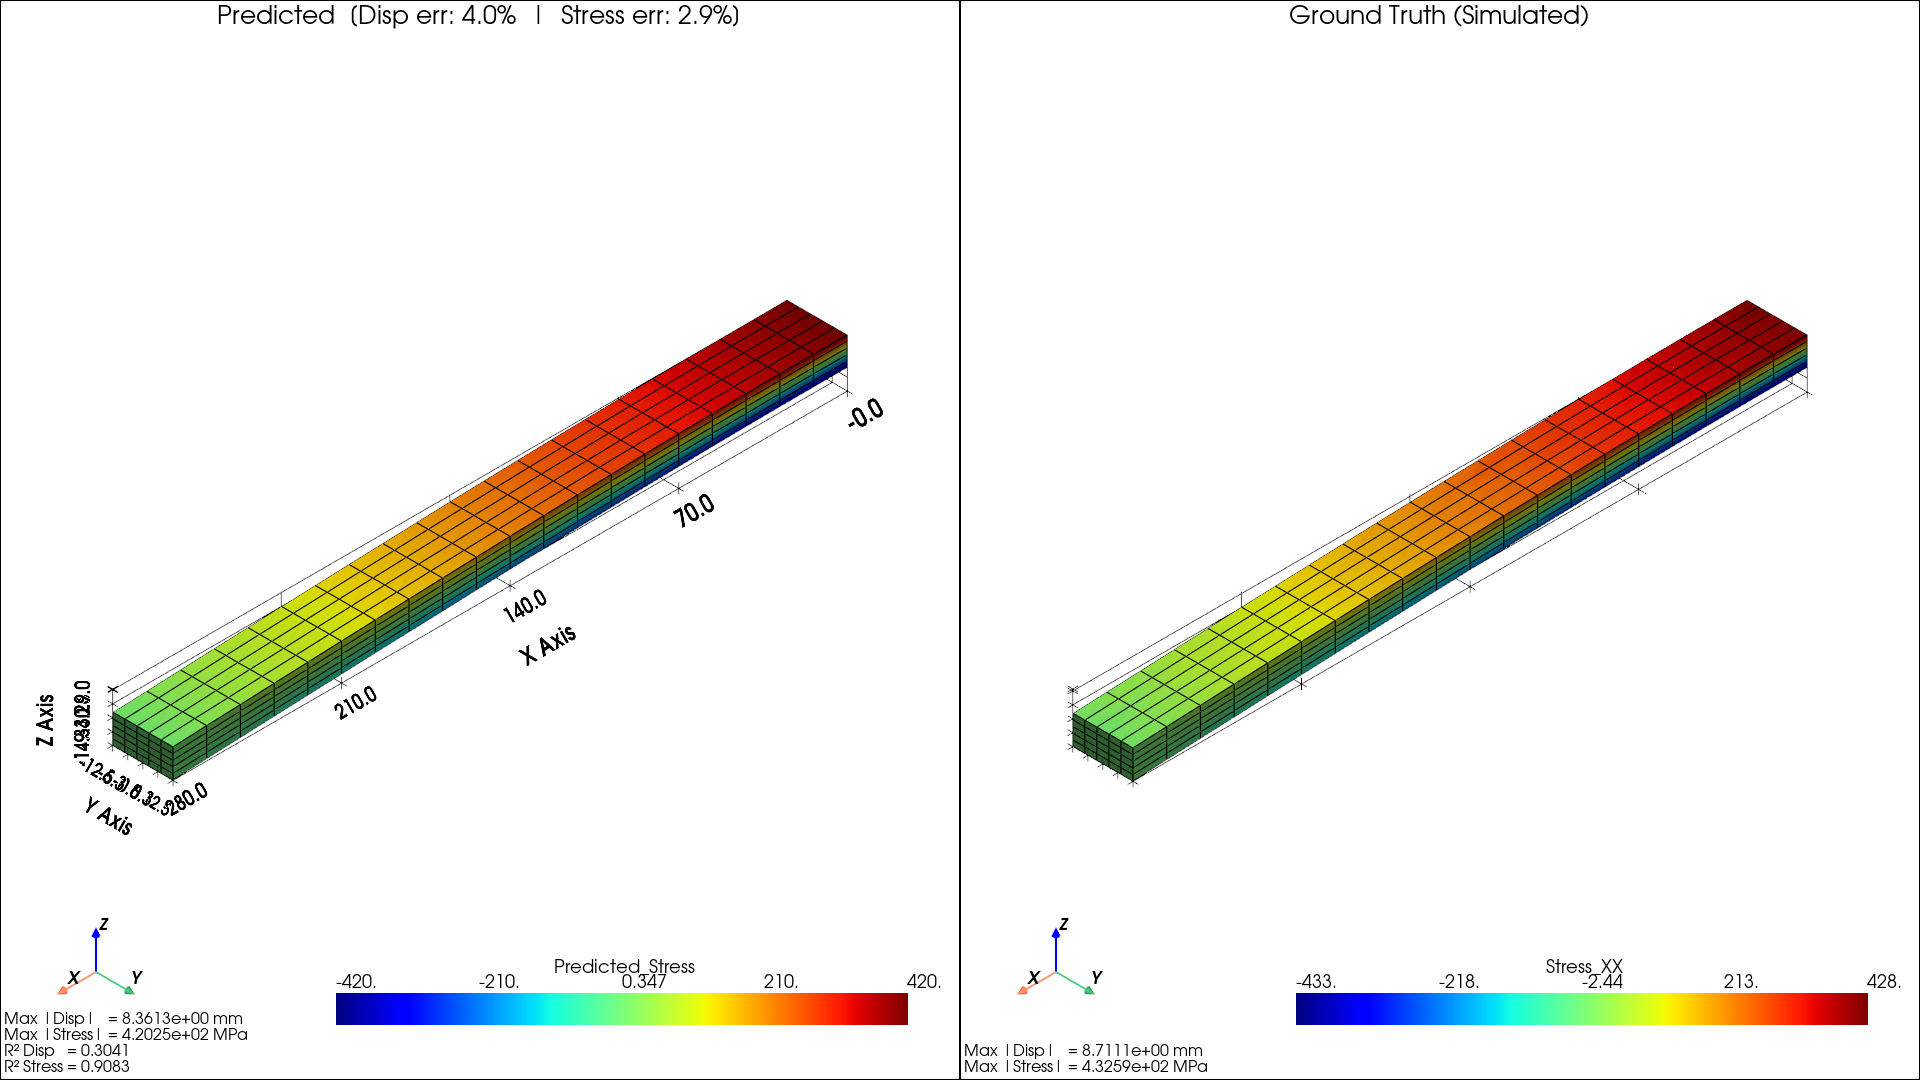

✓ Visualization saved to: e:\jimit.vyas\scripts\fea-ml-training\screenshots\predictions_transformer_lhs.png

Generating predictions for SOBOL sampling

>> Visualizing GCN predictions...


e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


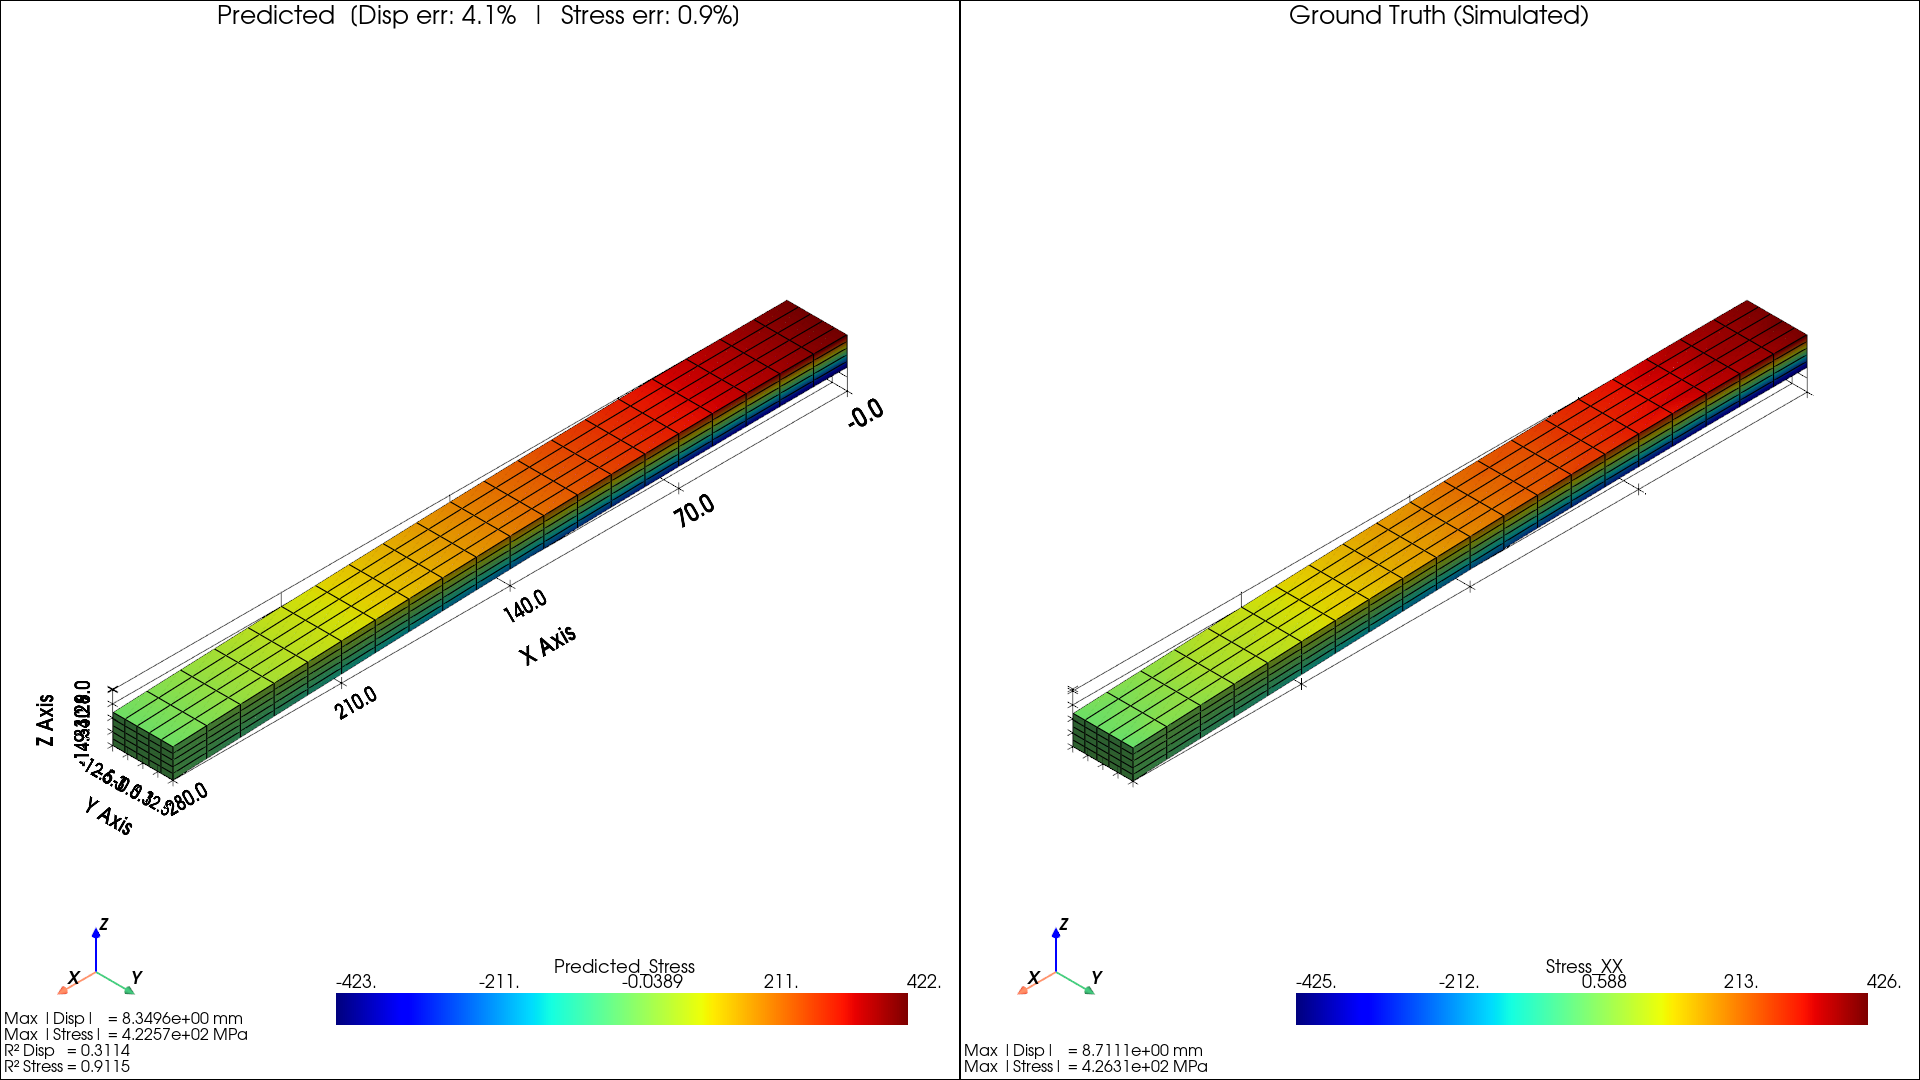

✓ Visualization saved to: e:\jimit.vyas\scripts\fea-ml-training\screenshots\predictions_gcn_sobol.png

>> Visualizing TRANSFORMER predictions...


e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (e:\jimit.vyas\scripts\fea-ml-training\.venv\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


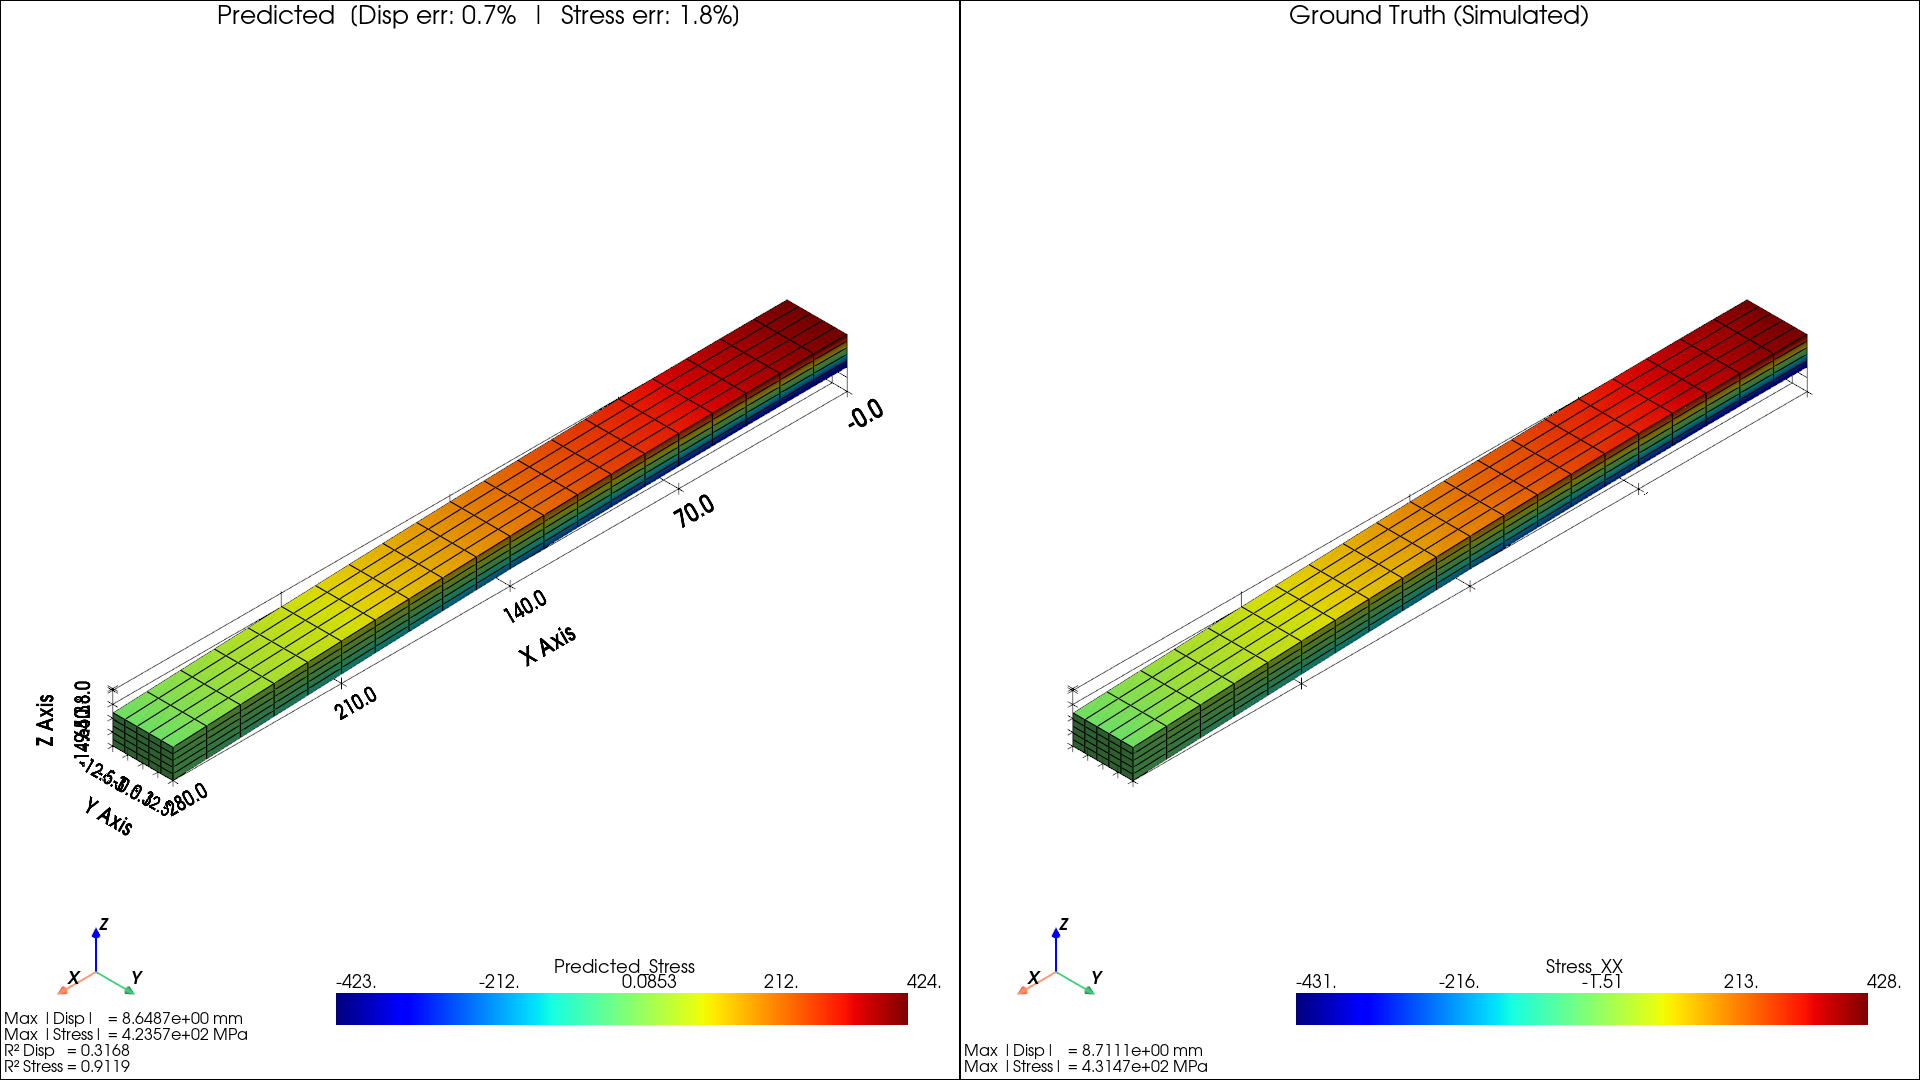

✓ Visualization saved to: e:\jimit.vyas\scripts\fea-ml-training\screenshots\predictions_transformer_sobol.png

All results generated successfully!


In [3]:
# Generate predictions and visualize results for each model
for sampling in samplings:
    print(f"\n{'='*60}")
    print(f"Generating predictions for {sampling.upper()} sampling")
    print(f"{'='*60}")
    
    for model_type in model_types:
        print(f"\n>> Visualizing {model_type.upper()} predictions...")
        
        viz = ROMVisualizer(
            model_dir=model_dir/model_type/sampling
        )
        
        # Define test geometry and loading condition
        l, w, d, load = 280, 25, 12, 900.0
        
        # Generate prediction and save screenshot
        screenshot_path = Path(f"screenshots/predictions_{model_type}_{sampling}.png")
        viz.predict_and_plot(l, w, d, load, screenshot=screenshot_path)
        
        print(f"✓ Visualization saved to: {screenshot_path.absolute()}")

print(f"\n{'='*60}")
print("All results generated successfully!")
print(f"{'='*60}")

## Step 6: Interactive Exploration (Optional)

Use this section to explore model predictions with different input parameters. You can manually adjust geometry and loading conditions to see how predictions change.

**How to use:**
1. Uncomment the code below
2. Modify the parameter values (length, width, depth, load)
3. Run the cell to see predictions for your custom inputs

**Valid Parameter Ranges:**
- Length: 100 - 500 mm
- Width: 20 - 50 mm
- Depth: 10 - 20 mm
- Load: 100 - 1000 N

In [ ]:
# ==============================================================================
# INTERACTIVE EXPLORATION - Customize and run to test different parameters
# ==============================================================================

# from pathlib import Path
# from src.visualizer import ROMVisualizer
# from src.input_visualizer import PointCloudVisualizer

# # Select configuration
# data_dir = Path("mock_data")
# model_dir = Path("models")
# model_type = "gcn"        # Choose: "gcn" or "transformer"
# sampling = "lhs"          # Choose: "random", "lhs", or "sobol"

# # Visualize the parameter space
# print(f"Visualizing {sampling.upper()} parameter space...")
# viz = PointCloudVisualizer(csv_path=data_dir/sampling/"design_table.csv")
# viz.load_data()
# viz.plot(symmetric_color_scale=True)

# # Make predictions with custom parameters
# print(f"\nMaking predictions with {model_type.upper()} model...")
# viz = ROMVisualizer(model_dir=model_dir/model_type/sampling)

# # CUSTOMIZE THESE PARAMETERS:
# length = 300   # mm (range: 100-500)
# width = 30     # mm (range: 20-50)
# depth = 15     # mm (range: 10-20)
# load = 800     # N  (range: 100-1000)

# # Generate and display predictions
# viz.predict_and_plot(length, width, depth, load)

# print(f"\nPrediction for: L={length}mm, W={width}mm, D={depth}mm, Load={load}N")

## Summary

You have successfully completed the FEA ML training pipeline:

✓ Generated synthetic FEA datasets using multiple sampling strategies  
✓ Visualized the parameter space to understand sampling coverage  
✓ Trained GCN and Transformer models on the generated data  
✓ Generated predictions and visualized results  

### Key Outputs

- **Trained Models**: Stored in `models/{model_type}/{sampling}/`
- **Training Logs**: Stored in `logs/` directory with TensorBoard metrics
- **Predictions**: Visual predictions saved in `screenshots/`

### Next Steps

1. **Analyze Training Results**: Check the logs to compare model performance across different sampling strategies
2. **Fine-tune Models**: Adjust training hyperparameters in `src/rom_model.py` and retrain
3. **Interactive Exploration**: Use Step 6 above to test predictions with custom parameters
4. **Deploy Models**: Package trained models for inference on new data

### References

- See `docs/` for detailed technical documentation
- Check `literature_review/` for relevant research papers
- Refer to `README.md` for project overview